In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

In [2]:
data_dir = Path('../Data')
results_dir = Path('../Results')
results_dir.mkdir(parents=True, exist_ok=True)

dt = 0.25
expected_rows = 35136
granular_periods = ['M01', 'M02', 'M03', 'Q2', 'Q3', 'Q4']
month_to_period = {1: 'M01', 2: 'M02', 3: 'M03', 4: 'Q2', 5: 'Q2', 6: 'Q2', 7: 'Q3', 8: 'Q3', 9: 'Q3', 10: 'Q4', 11: 'Q4', 12: 'Q4'}

slp = pd.read_csv(data_dir / 'slp_profiles.csv')
futures = pd.read_csv(data_dir / 'futures_prices.csv')
hpfc = pd.read_csv(results_dir / 'GRANULAR_hpfc_curve.csv')

In [3]:
slp['timestamp_utc'] = pd.to_datetime(slp['timestamp_utc'], utc=True)
hpfc['timestamp_utc'] = pd.to_datetime(hpfc['timestamp_local'], utc=True)
hpfc['timestamp_local'] = hpfc['timestamp_utc'].dt.tz_convert('Europe/Berlin')

input_checks = pd.DataFrame([{'Input': 'SLP', 'Rows': len(slp), 'Unique UTC': slp['timestamp_utc'].nunique(), 'Missing': slp.isna().sum().sum()}, {'Input': 'GRANULAR HPFC', 'Rows': len(hpfc), 'Unique UTC': hpfc['timestamp_utc'].nunique(), 'Missing': hpfc.isna().sum().sum()}])
assert input_checks['Rows'].eq(expected_rows).all()
assert input_checks['Unique UTC'].eq(expected_rows).all()
assert input_checks['Missing'].eq(0).all()
assert hpfc['timestamp_utc'].equals(slp['timestamp_utc'])
display(input_checks)

,Input,Rows,Unique UTC,Missing
0,SLP,35136,35136,0
1,GRANULAR HPFC,35136,35136,0


## Futures hedge

**Inputs:** the forecast portfolio from `00_Exhibits.ipynb`, the contract-consistent granular HPFC from `01_HPFC.ipynb`, and `futures_prices.csv`.

The HPFC is denoted by

$$
HPFC_t := \bar{\pi}_t.
$$

For futures positions $x_j$, the hedge energy in interval $t$ is

$$
H_t = \Delta t \sum_j x_j D_{j,t},
\qquad
\Delta t = 0.25\,\mathrm{h}.
$$

Within optimization block $b$, define

$$
x_b := \begin{bmatrix} x_{B,b} \\ x_{P,b} \end{bmatrix},
\qquad
I_t^P := \begin{cases} 1, & \text{Peak interval} \\ 0, & \text{Off-Peak interval}. \end{cases}
$$

The block delivery matrix already includes the quarter-hour duration:

$$
D_b = \begin{bmatrix} 0.25 & 0.25 I_1^P \\ 0.25 & 0.25 I_2^P \\ \vdots & \vdots \\ 0.25 & 0.25 I_{N_b}^P \end{bmatrix},
\qquad
H_b = D_b x_b,
$$

$$
H_t = 0.25x_{B,b} + 0.25I_t^P x_{P,b}.
$$

In [4]:
annual_energy_mwh = {'HB': 35000.0, 'GB': 6000.0, 'LB': 2000.0}
profile_columns = {'HB': 'hb_normalized_kwh', 'GB': 'gb_normalized_kwh', 'LB': 'lb_normalized_kwh'}

forecast = slp[['timestamp_utc']].copy()
forecast['timestamp_local'] = forecast['timestamp_utc'].dt.tz_convert('Europe/Berlin')
for profile, column in profile_columns.items():
    forecast[f'{profile.lower()}_mwh'] = slp[column] * annual_energy_mwh[profile] / slp[column].sum()
forecast['forecast_mwh'] = forecast[['hb_mwh', 'gb_mwh', 'lb_mwh']].sum(axis=1)

hedge_data = forecast.merge(hpfc[['timestamp_utc', 'hpfc_eur_mwh']], on='timestamp_utc', how='left', validate='one_to_one')
hedge_data['is_peak'] = ((hedge_data['timestamp_local'].dt.dayofweek < 5) & (hedge_data['timestamp_local'].dt.hour >= 8) & (hedge_data['timestamp_local'].dt.hour < 20)).astype(int)
hedge_data['optimization_period'] = hedge_data['timestamp_local'].dt.month.map(month_to_period)

portfolio_reconciliation = pd.DataFrame({'Profile': ['HB', 'GB', 'LB', 'Total'], 'Expected MWh': [35000.0, 6000.0, 2000.0, 43000.0], 'Calculated MWh': [forecast['hb_mwh'].sum(), forecast['gb_mwh'].sum(), forecast['lb_mwh'].sum(), forecast['forecast_mwh'].sum()]})
portfolio_reconciliation['Difference MWh'] = portfolio_reconciliation['Calculated MWh'] - portfolio_reconciliation['Expected MWh']
assert len(hedge_data) == expected_rows and hedge_data.isna().sum().sum() == 0
assert np.allclose(portfolio_reconciliation['Calculated MWh'], portfolio_reconciliation['Expected MWh'])
display(portfolio_reconciliation.round(6))

,Profile,Expected MWh,Calculated MWh,Difference MWh
0,HB,35000.0,35000.0,0.0
1,GB,6000.0,6000.0,0.0
2,LB,2000.0,2000.0,-0.0
3,Total,43000.0,43000.0,0.0


## KKT conditions

The block-level problem minimizes forecast-load mismatch while matching the forecast and hedge values:

$$
\min_{x_b} \frac{1}{2}(L_b-D_bx_b)^T(L_b-D_bx_b)
$$

subject to

$$
a_b^T x_b = c_b,
\qquad
x_b \geq 0,
$$

where

$$
c_b = L_b^T\pi_b,
\qquad
a_b = D_b^T\pi_b.
$$

The Lagrangian is

$$
\mathcal{L}(x_b,\lambda_b,\mu_b)=\frac{1}{2}(L_b-D_bx_b)^T(L_b-D_bx_b)+\lambda_b(a_b^T x_b-c_b)-\mu_b^T x_b,
$$

with $\mu_b=(\mu_B,\mu_P)^T$. The KKT conditions are

$$
\nabla_{x_b}\mathcal{L}(x_b;\lambda_b,\mu_b)=0,
\qquad
a_b^T x_b=c_b,
$$

$$
x_{j,b}\geq0,
\qquad
\mu_j\geq0,
\qquad
\lambda_b\in\mathbb{R},
\qquad
\mu_jx_j=0,
\qquad j\in\{B,P\}.
$$

For an interior solution, $x_{j,b}>0\Rightarrow\mu_j=0$, and

$$
D_b^TD_bx_b+\lambda_ba_b=D_b^TL_b.
$$

Therefore,

$$
\begin{bmatrix} D_b^TD_b & a_b \\ a_b^T & 0 \end{bmatrix}\begin{bmatrix} x_b \\ \lambda_b \end{bmatrix}=\begin{bmatrix} D_b^TL_b \\ c_b \end{bmatrix}.
$$

The code also evaluates the Base-only and Peak-only boundaries and retains the feasible candidate with the smallest squared mismatch.

In [5]:
strategy_periods = {'UNHEDGED': [], 'COARSE_CAL': ['CAL'], 'GRANULAR': granular_periods}
strategy_timeseries = {}
position_rows = []
value_check_rows = []
future_quotes = futures.set_index(['delivery_period', 'load_type'])['price_eur_mwh']
assert future_quotes.index.is_unique

for strategy, periods in strategy_periods.items():
    hedge_energy = np.zeros(len(hedge_data))
    futures_interval_cost = np.zeros(len(hedge_data))

    if strategy != 'UNHEDGED':
        for period in periods:
            period_mask = np.ones(len(hedge_data), dtype=bool) if period == 'CAL' else hedge_data['optimization_period'].eq(period).to_numpy()
            period_load = hedge_data.loc[period_mask, 'forecast_mwh'].to_numpy()
            period_hpfc = hedge_data.loc[period_mask, 'hpfc_eur_mwh'].to_numpy()
            period_peak = hedge_data.loc[period_mask, 'is_peak'].to_numpy()
            delivery = np.column_stack([np.full(period_mask.sum(), dt), period_peak * dt])
            value_coefficients = delivery.T @ period_hpfc
            forecast_value = period_load @ period_hpfc
            gram = delivery.T @ delivery
            kkt = np.block([[gram, value_coefficients[:, None]], [value_coefficients[None, :], np.zeros((1, 1))]])
            equality_solution = np.linalg.solve(kkt, np.r_[delivery.T @ period_load, forecast_value])[:2]
            candidates = [equality_solution, np.array([forecast_value / value_coefficients[0], 0.0]), np.array([0.0, forecast_value / value_coefficients[1]])]
            candidates = [np.maximum(candidate, 0) for candidate in candidates if candidate.min() >= -1e-10]
            positions = min(candidates, key=lambda candidate: np.square(period_load - delivery @ candidate).sum())
            period_hedge = delivery @ positions
            hedge_energy[period_mask] = period_hedge

            for column, load_type in enumerate(['BASE', 'PEAK']):
                product_delivery = delivery[:, column]
                quoted_price = future_quotes.loc[(period, load_type)]
                notional_mwh = positions[column] * product_delivery.sum()
                futures_interval_cost[period_mask] += positions[column] * product_delivery * quoted_price
                position_rows.append({'Strategy': strategy, 'Period': period, 'Load Type': load_type, 'Position MW': positions[column], 'Notional MWh': notional_mwh, 'Price EUR/MWh': quoted_price, 'Futures Cost EUR': notional_mwh * quoted_price})

            value_check_rows.append({'Strategy': strategy, 'Block': period, 'Forecast Value EUR': forecast_value, 'Hedge Value EUR': period_hedge @ period_hpfc, 'Value-Neutrality Error EUR': period_hedge @ period_hpfc - forecast_value})

    strategy_data = hedge_data[['timestamp_utc', 'timestamp_local', 'optimization_period', 'is_peak', 'forecast_mwh', 'hpfc_eur_mwh']].copy()
    strategy_data['hedge_energy_mwh'] = hedge_energy
    strategy_data['futures_interval_cost_eur'] = futures_interval_cost
    strategy_data['day_ahead_residual_mwh'] = strategy_data['forecast_mwh'] - strategy_data['hedge_energy_mwh']
    strategy_timeseries[strategy] = strategy_data

hedge_positions = pd.DataFrame(position_rows)
value_neutrality_checks = pd.DataFrame(value_check_rows)

In [6]:
hedge_rows = []
forecast_hpfc_value = (hedge_data['forecast_mwh'] * hedge_data['hpfc_eur_mwh']).sum()
for strategy, strategy_data in strategy_timeseries.items():
    hedge_hpfc_value = (strategy_data['hedge_energy_mwh'] * strategy_data['hpfc_eur_mwh']).sum()
    strategy_errors = value_neutrality_checks.loc[value_neutrality_checks['Strategy'].eq(strategy), 'Value-Neutrality Error EUR']
    hedge_rows.append({'Strategy': strategy, 'Hedge Notional MWh': strategy_data['hedge_energy_mwh'].sum(), 'Forecast Value EUR': forecast_hpfc_value, 'Hedge Value EUR': hedge_hpfc_value, 'Max Absolute Value Error EUR': strategy_errors.abs().max() if len(strategy_errors) else np.nan, 'Residual-Load RMSE MWh': np.sqrt(np.mean(np.square(strategy_data['day_ahead_residual_mwh']))), 'Absolute Residual DA Volume MWh': strategy_data['day_ahead_residual_mwh'].abs().sum()})
hedge_summary = pd.DataFrame(hedge_rows)

print(hedge_positions.round({'Position MW': 4, 'Notional MWh': 2, 'Price EUR/MWh': 2, 'Futures Cost EUR': 2}).to_string(index=False))
print('\n' + hedge_summary.round({'Hedge Notional MWh': 2, 'Forecast Value EUR': 2, 'Hedge Value EUR': 2, 'Max Absolute Value Error EUR': 8, 'Residual-Load RMSE MWh': 5, 'Absolute Residual DA Volume MWh': 2}).to_string(index=False))

  Strategy Period Load Type  Position MW  Notional MWh  Price EUR/MWh  Futures Cost EUR
COARSE_CAL    CAL      BASE       4.3920      38579.12          77.26        2980622.64
COARSE_CAL    CAL      PEAK       1.8844       5924.70          86.60         513079.09
  GRANULAR    M01      BASE       5.0437       3752.48          75.32         282636.72
  GRANULAR    M01      PEAK       2.3310        643.35          88.68          57052.22
  GRANULAR    M02      BASE       4.9331       3433.43          60.09         206314.91
  GRANULAR    M02      PEAK       2.2172        558.74          70.59          39441.59
  GRANULAR    M03      BASE       4.6509       3455.61          63.45         219258.41
  GRANULAR    M03      PEAK       1.9714        496.79          72.79          36161.06
  GRANULAR     Q2      BASE       4.0000       8735.97          66.23         578583.09
  GRANULAR     Q2      PEAK       1.6782       1309.02          64.76          84772.10
  GRANULAR     Q3      BASE     

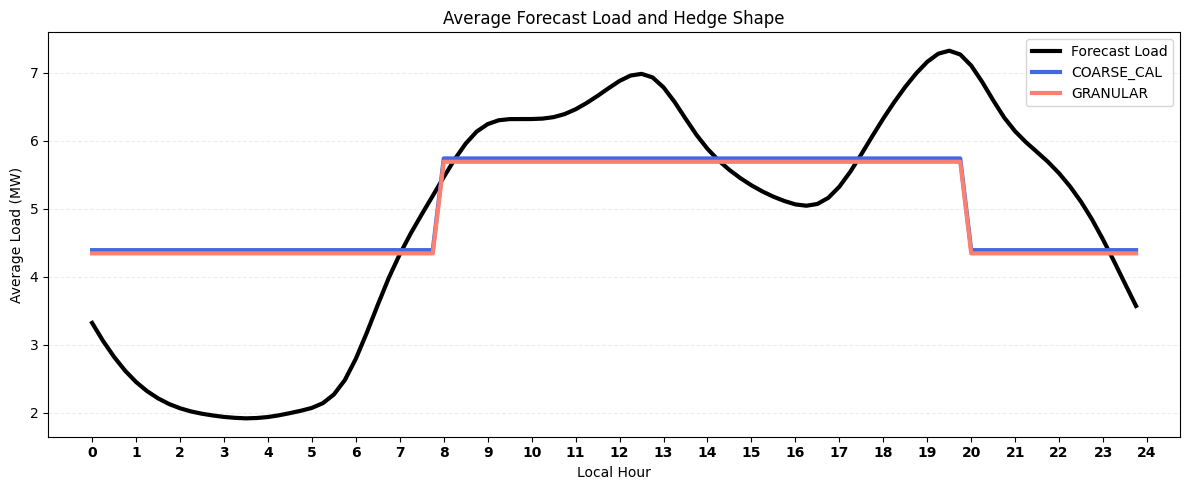

In [7]:
hedge_data['local_quarter'] = hedge_data['timestamp_local'].dt.hour * 4 + hedge_data['timestamp_local'].dt.minute // 15
daily_shape = hedge_data.groupby('local_quarter')['forecast_mwh'].mean().to_frame('Forecast Load')
for strategy in ['COARSE_CAL', 'GRANULAR']:
    daily_shape[strategy] = strategy_timeseries[strategy].assign(local_quarter=hedge_data['local_quarter']).groupby('local_quarter')['hedge_energy_mwh'].mean()
daily_shape.index = daily_shape.index / 4

plt.figure(figsize=(12, 5))
plt.plot(daily_shape.index, daily_shape['Forecast Load'] / dt, color='black', linewidth=3, label='Forecast Load')
plt.plot(daily_shape.index, daily_shape['COARSE_CAL'] / dt, color='royalblue', linewidth=3, label='COARSE_CAL')
plt.plot(daily_shape.index, daily_shape['GRANULAR'] / dt, color='salmon', linewidth=3, label='GRANULAR')
plt.title('Average Forecast Load and Hedge Shape')
plt.xlabel('Local Hour')
plt.ylabel('Average Load (MW)')
plt.xticks(np.arange(0, 25, 1), fontsize=10, fontweight='heavy')
plt.xlim(-1, 24.75)
plt.grid(axis='y', linestyle='--', color='lightgray', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(results_dir / '02 Average Forecast Load and Hedge Shape.png', dpi=144, transparent=True)
plt.show()

In [8]:
hedge_timeseries = hedge_data[['timestamp_utc', 'timestamp_local', 'forecast_mwh', 'is_peak', 'optimization_period', 'hpfc_eur_mwh']].copy()
output_columns = {'UNHEDGED': ('hedge_unhedged_mwh', 'residual_unhedged_mwh', 'futures_cost_unhedged_eur'), 'COARSE_CAL': ('hedge_coarse_mwh', 'residual_coarse_cal_mwh', 'futures_cost_coarse_eur'), 'GRANULAR': ('hedge_granular_mwh', 'residual_granular_mwh', 'futures_cost_granular_eur')}
for strategy, strategy_data in strategy_timeseries.items():
    hedge_column, residual_column, futures_cost_column = output_columns[strategy]
    hedge_timeseries[hedge_column] = strategy_data['hedge_energy_mwh']
    hedge_timeseries[residual_column] = strategy_data['day_ahead_residual_mwh']
    hedge_timeseries[futures_cost_column] = strategy_data['futures_interval_cost_eur']

hedge_positions.to_csv(results_dir / '02_futures_positions.csv', index=False)
value_neutrality_checks.to_csv(results_dir / '02_value_neutrality_checks.csv', index=False)
hedge_summary.to_csv(results_dir / '02_hedge_summary.csv', index=False)
hedge_timeseries.to_csv(results_dir / '02_hedge_timeseries.csv', index=False)

output_files = ['02_futures_positions.csv', '02_value_neutrality_checks.csv', '02_hedge_summary.csv', '02_hedge_timeseries.csv', '02 Average Forecast Load and Hedge Shape.png']
hedging_checks = pd.DataFrame([{'Check': 'Aligned quarter-hour rows', 'Observed': len(hedge_timeseries), 'Expected': expected_rows, 'Passed': len(hedge_timeseries) == expected_rows}, {'Check': 'Forecast portfolio reconciliation', 'Observed': hedge_timeseries['forecast_mwh'].sum(), 'Expected': 43000.0, 'Passed': np.isclose(hedge_timeseries['forecast_mwh'].sum(), 43000.0)}, {'Check': 'Non-negative futures positions', 'Observed': hedge_positions['Position MW'].min(), 'Expected': '>= 0', 'Passed': hedge_positions['Position MW'].ge(-1e-10).all()}, {'Check': 'Value-neutrality errors below one cent', 'Observed': value_neutrality_checks['Value-Neutrality Error EUR'].abs().max(), 'Expected': '< 0.01 EUR', 'Passed': value_neutrality_checks['Value-Neutrality Error EUR'].abs().max() < 0.01}, {'Check': 'All Results outputs exist', 'Observed': sum((results_dir / name).exists() for name in output_files), 'Expected': len(output_files), 'Passed': all((results_dir / name).exists() for name in output_files)}])
hedging_checks.to_csv(results_dir / '02_hedging_checks.csv', index=False)
assert hedging_checks['Passed'].all()
display(hedging_checks)
print(f"{hedging_checks['Passed'].sum()} of {len(hedging_checks)} checks passed")

,Check,Observed,Expected,Passed
0,Aligned quarter-hour rows,3.513600e+04,35136,True
1,Forecast portfolio reconciliation,4.300000e+04,43000.0,True
2,Non-negative futures positions,1.541214e+00,>= 0,True
3,Value-neutrality errors below one cent,2.468005e-08,< 0.01 EUR,True
4,All Results outputs exist,5.000000e+00,5,True


5 of 5 checks passed


### Interpretation

- `COARSE_CAL` applies one annual Base/Peak pair; `GRANULAR` applies separate Base/Peak pairs to M01-M03 and Q2-Q4.
- Peak MW is incremental above Base MW, so both positions deliver during Peak intervals.
- Value neutrality is price-weighted and does not imply physical-volume neutrality.
- The optimization uses only the 2023-09-29 futures snapshot, the forecast portfolio, and the ex-ante HPFC. Realised 2024 Day-Ahead prices, actual load, and reBAP remain outside hedge design and enter only the subsequent cost analysis.
- A lower in-sample residual-load mismatch does not by itself establish lower realised procurement cost or lower risk.